In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent, PRICE_MAPPER
from config_local import config
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

logger = logging.getLogger(__name__)

/home/markoc1120/src/nlp_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1>Wikispeedia dataset exploratory analysis</h1>

Let's get started by exploring the Wikispeedia dataset. The dataset is composed of six files:

articles.tsv, which contains the list of wikipedia articles


categories.tsv, which contains the list of wikipedia categories


links.tsv, which contains the list of links between articles


paths_finished.tsv, which contains the list of human paths finished by the users


paths_unfinished.tsv, which contains the list of human paths unfinished by the users


shortest-path-distance-matrix.txt, which contains the shortest path distance between each pair of articles


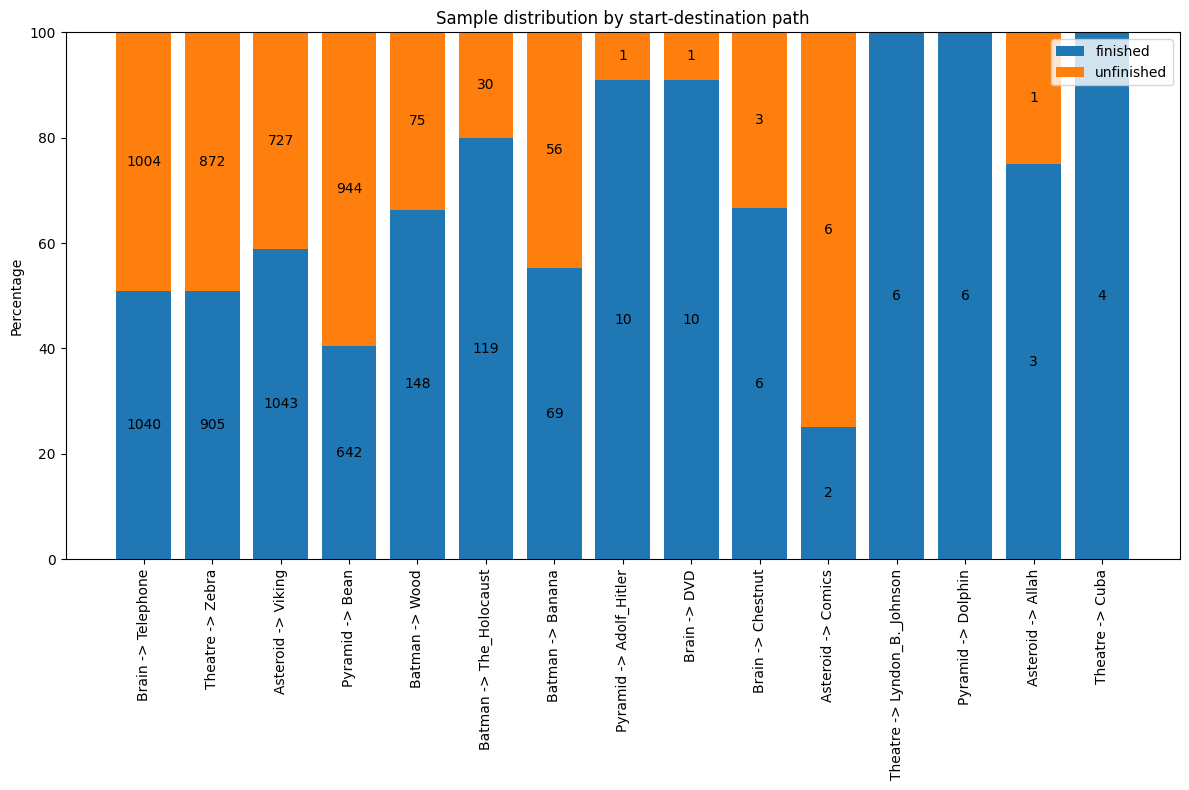

In [3]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

As shown above, we have a few start-destination pairs with a high number of paths.

<h3>Articles</h3>

In [4]:
# parsing auxiliary files into pd.DataFrame
articles = preprocessor.parse_input_file(config.input_file_articles)
categories = preprocessor.parse_input_file(config.input_file_categories)
links = preprocessor.parse_input_file(config.input_file_links)

In [5]:
# number of articles
print(f'Number of articles: {len(articles)}')

Number of articles: 4604


<h3>Links</h3>  

All of the articles have at least one outgoing or target link, thus we don't have any links which are unreachable. On average, each article appears ~26 times as source and ~29 as target.

*Source links' statistics*:

In [6]:
print(links['linkSource'].value_counts().describe())

count    4587.000000
mean       26.135165
std        24.194229
min         1.000000
25%        11.000000
50%        19.000000
75%        33.000000
max       294.000000
Name: count, dtype: float64


*Target links' statistics*:

In [7]:
print(links['linkTarget'].value_counts().describe())

count    4135.000000
mean       28.992019
std        65.560574
min         1.000000
25%         4.000000
50%        10.000000
75%        29.000000
max      1551.000000
Name: count, dtype: float64


<h3>Categories</h3>

We have 129 unique categories. Each articles has at most 3 categories. 

*Categories statistics*:

In [8]:
categories.describe()

,article,category
count,5204,5204
unique,4598,129
top,United_Kingdom,subject.Countries
freq,3,229


There are 43379 articles without categories (9.11%)

In [9]:
cat_df_clean, cat_df, article_cats_finished, article_cats = preprocessor.get_clean_categories_df(df, categories)

In [10]:
# Count missing categories
mis_count = cat_df.loc[cat_df["category"] == "Unknown", "count"].sum()
mis_perc = mis_count / len(article_cats) 

# Prints
print(f"'No. of unknown categories: {mis_count}")
print(f"'Unknown' categories account for approximately {mis_perc:.2%} of all entries.")

'No. of unknown categories: 33559
'Unknown' categories account for approximately 7.05% of all entries.


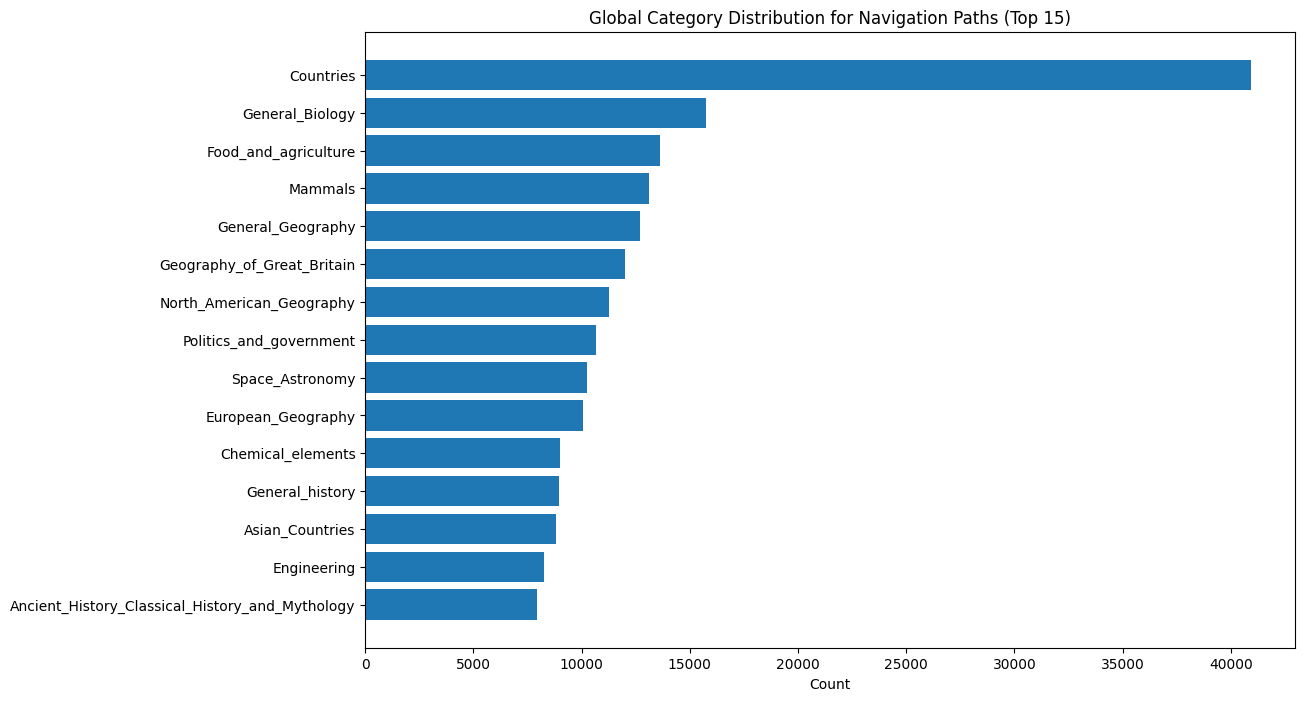

In [11]:
# Plot the 15 top categories while excluding missing categories
visualizer.visualize_category_distribution_for_paths(cat_df_clean, 'top_15_categories.png')

Countries is by far the most visited category

<h3>Categorical Shifts</h3>

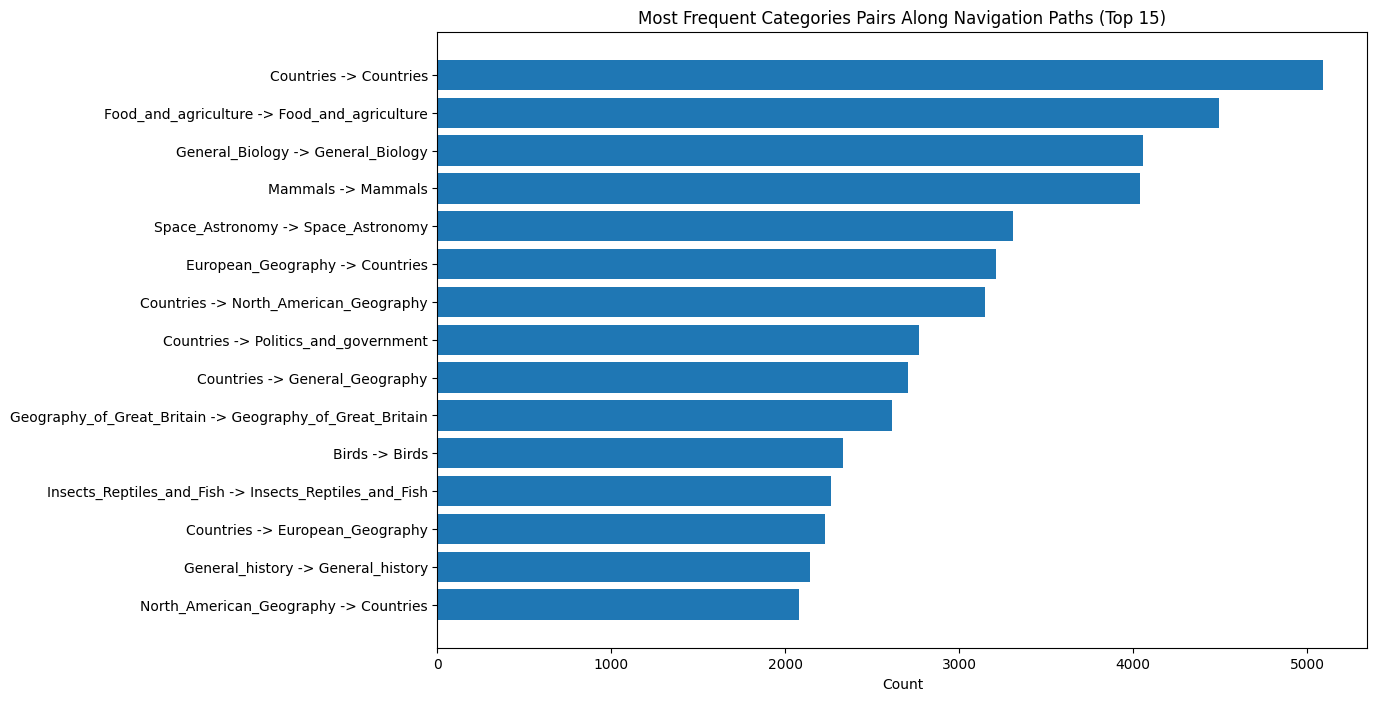

In [12]:
cat_shift_df_filter = preprocessor.get_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_categorical_shifts(cat_shift_df_filter, 'top_categorical_shifts.png')

The most frequent categories often occur for same categories, i.e., the user traverse articles within the same category. Below we exclude same category pairs.

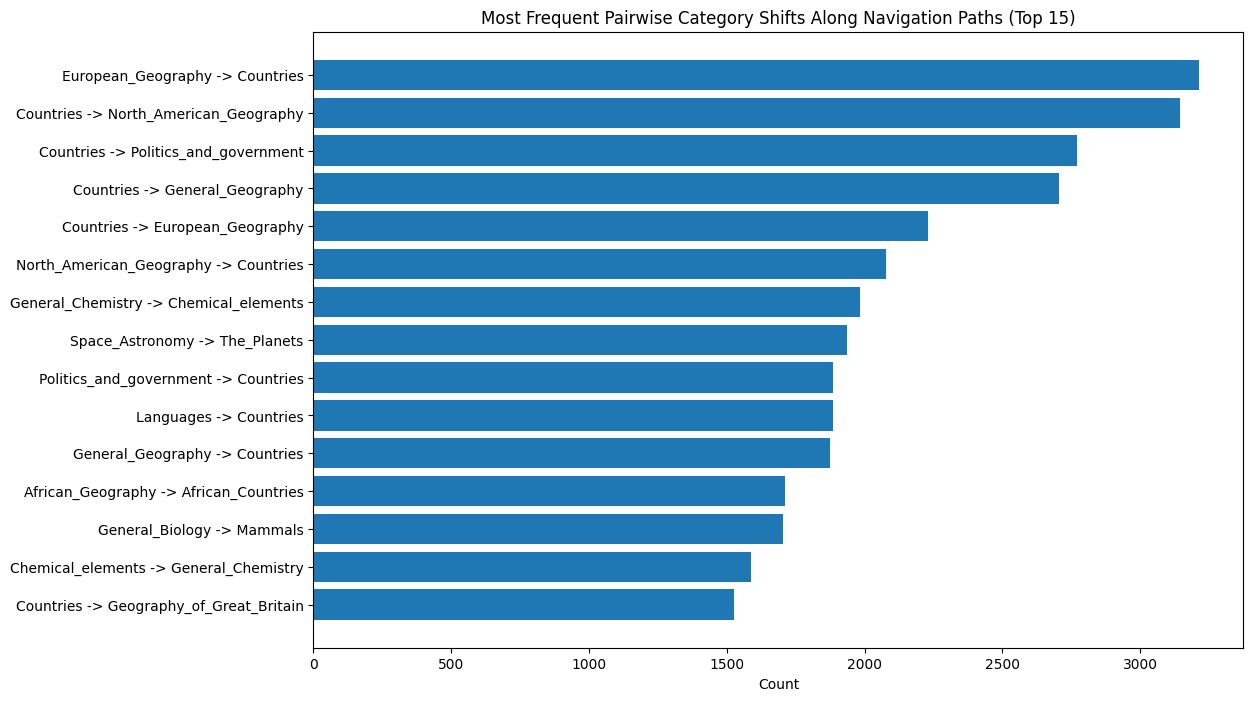

In [13]:
cat_shift_df_filter = preprocessor.get_pairwise_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_pairwise_categorical_shifts(cat_shift_df_filter, 'top_pairwise_categorical_shifts.png')

The 15 most frequent pairwise category shifts are categories that are related. 

Visualizing the categorical drifts along nagivation for a finished path: Interactive only inside notebook (see cat_shift.png for static image)

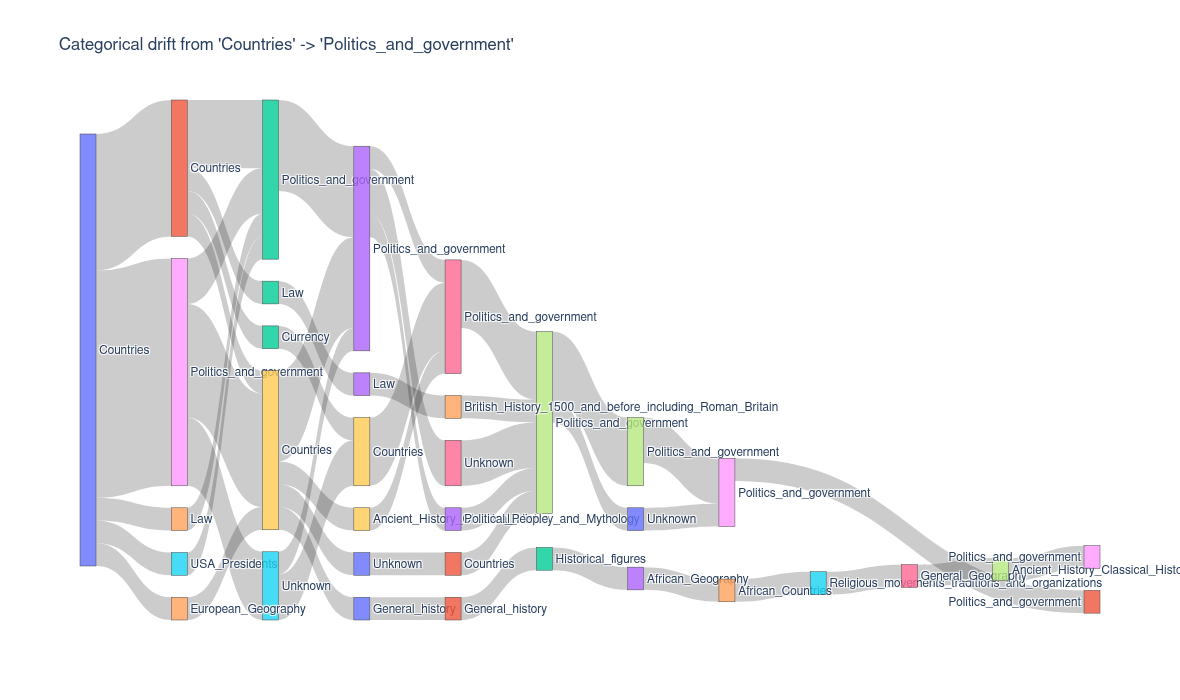

In [14]:
# Define start and end category
start_cat, end_cat = "Countries", "Politics_and_government"
cat_shift_df_pairs = preprocessor.get_category_shifts_df_pairs(article_cats_finished, start_cat, end_cat)

# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot.png'
visualizer.visualize_sankey_plot(cat_shift_df_pairs, filename, start_cat, end_cat)

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

<h3>Paths</h3>

We have access to many paths; there are 51,318 finished paths in total and 24,875 unfinished paths.

In [15]:
#number of finished vs unfinished paths
print('num of finished paths:', len(df[df['target'].isnull()]))
print('num of unfinished paths:', len(df[df['target'].notnull()]))

num of finished paths: 51318
num of unfinished paths: 24875


some paths have '<' in them, indicating backtracking by human players

we can simply resolve them by skipping back to the previous article and continuing from there

In [16]:
df[df['path'].astype(str).str.contains('<')].head(10)['path']

10    14th_century;Time;Science;Nature;Weather;Sunli...
13    14th_century;Renaissance;Empiricism;Nature;Wea...
14    14th_century;Renaissance;Leonardo_da_Vinci;Wat...
16    14th_century;Europe;Republic_of_Ireland;<;<;Eu...
19    14th_century;Time;Physics;<;Day;Sun;Sunlight;U...
36    14th_century;England;London;Spanish_Armada;Eng...
41    14th_century;Europe;<;England;<;Christianity;A...
42    2004_Atlantic_hurricane_season;U.S._state;Unit...
47    2004_Atlantic_hurricane_season;El_Niño-Souther...
49    2004_Atlantic_hurricane_season;Atlantic_Ocean;...
Name: path, dtype: object

In [17]:
resolved_df = preprocessor.resolve_all_parsed_paths(df.copy())

In [18]:
#check if all '<' are resolved
print('num of paths with < after resolution:', resolved_df['path'].astype(str).str.contains('<').sum())

num of paths with < after resolution: 0


Some finished paths have a length of 1, indicating that the player is already at the target article, so we can simply remove those paths


In [19]:
print('num of finished paths with length 1 before removal:', len(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)]))

num of finished paths with length 1 before removal: 11


In [20]:
# remove finished paths with length 1
filtered_finished_paths = resolved_df.drop(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)].index)

<h3>Difficulties</h3>

Lets get the distribution of difficulties for finished and unfinished paths:

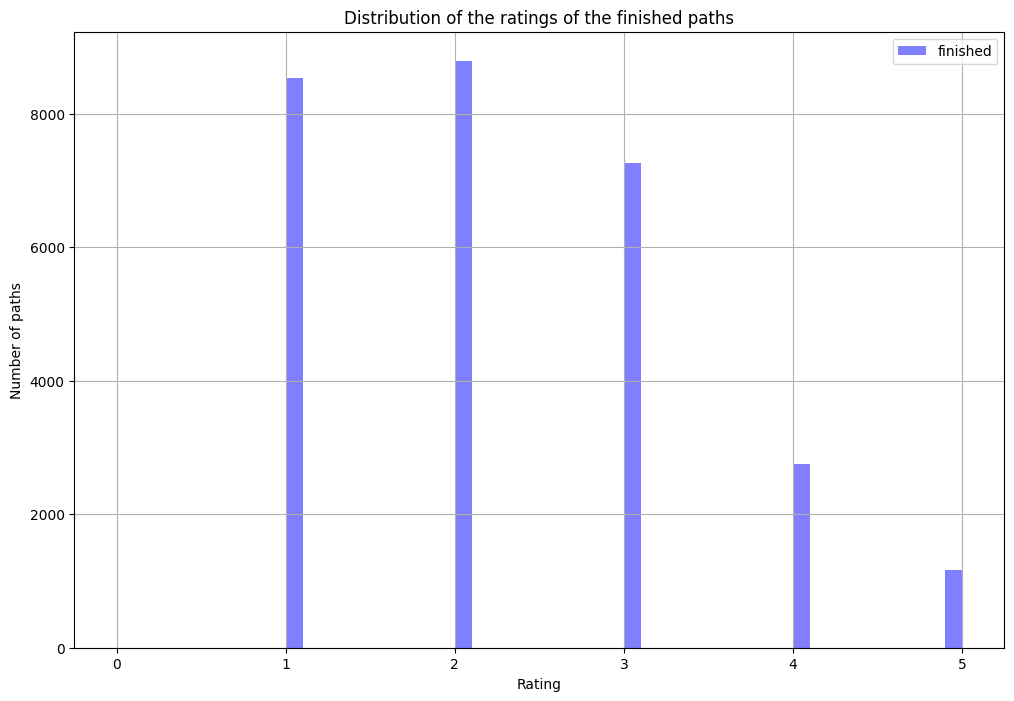

In [21]:
#get the distribution of difficulties for finished and unfinished paths
visualizer.visualize_ratings_distribution(filtered_finished_paths, 'ratings_distribution.png')

The rating distribution is imbalanced, so before conducting our further experiments, we can potentially stratify the dataset based on rating.

<h3>Durations</h3>

We are interested in the distribution of durations for unfinished paths:

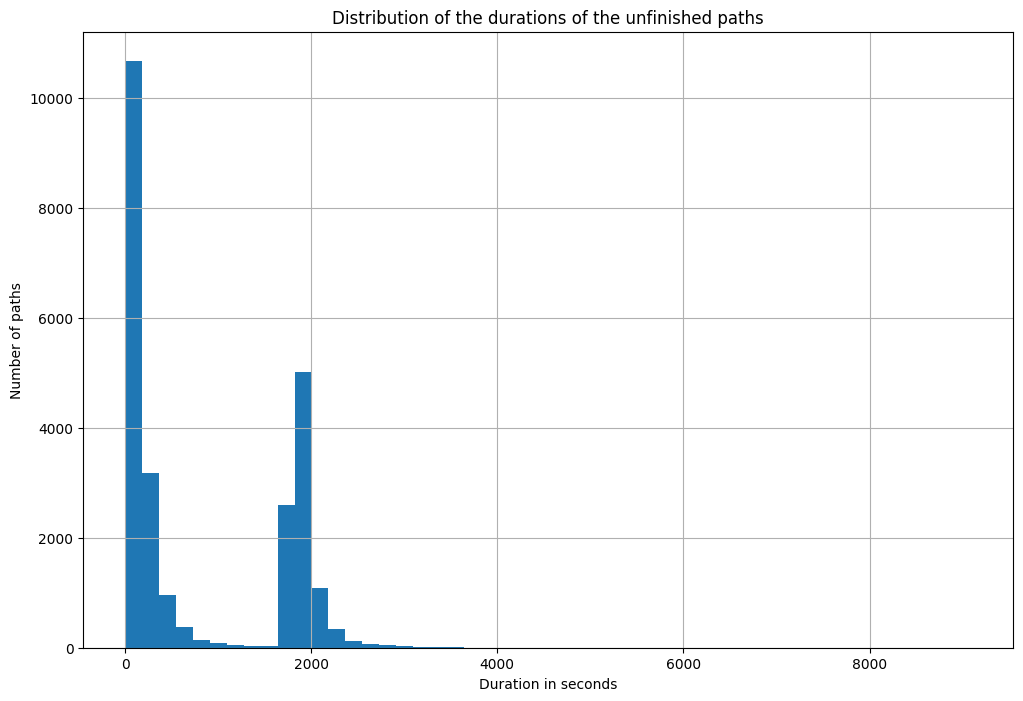

In [22]:
#Duration and rating correlation
visualizer.visualize_duration_distribution_unfinished(df, 'unfinished_duration_distribution.png')

Unfinished paths have two types: restart and timeout. It is two distinct distributions! Timeouts are longer.

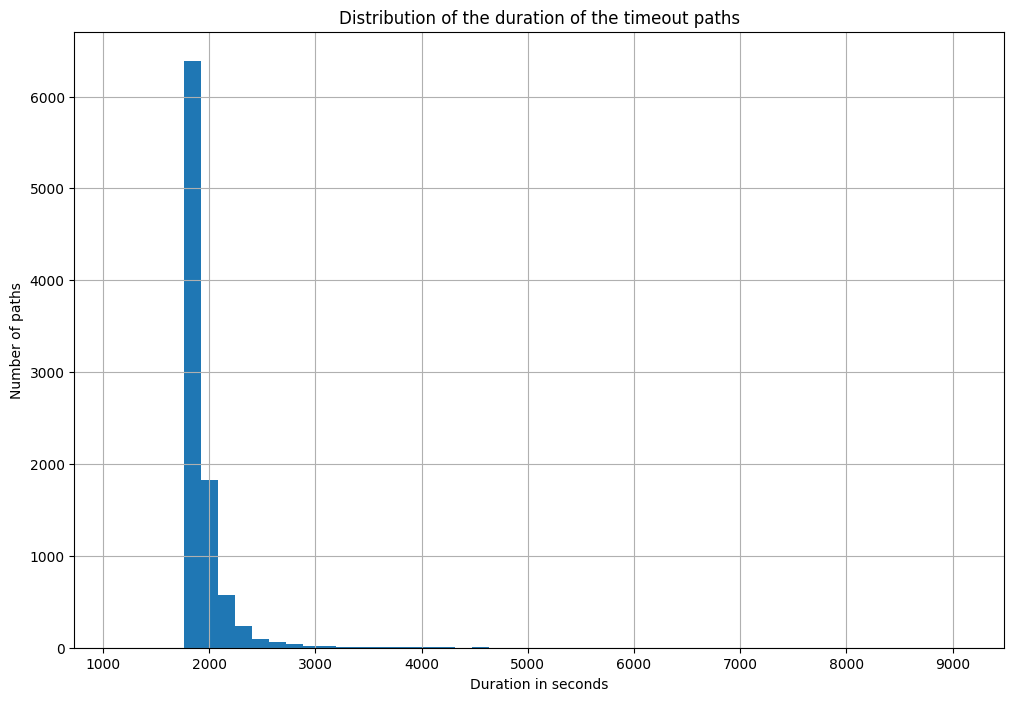

In [23]:
visualizer.visualize_duration_distribution_unfinished_timeout(df, 'unfinished_duration_distribution_timeout.png')

The plot confirms that the duration of timeout paths are an independent distribution from restart paths.

<h3>Semantics</h3>

We can visualize the semantic space of all articles using their embeddings obtained by sentence transformers:   

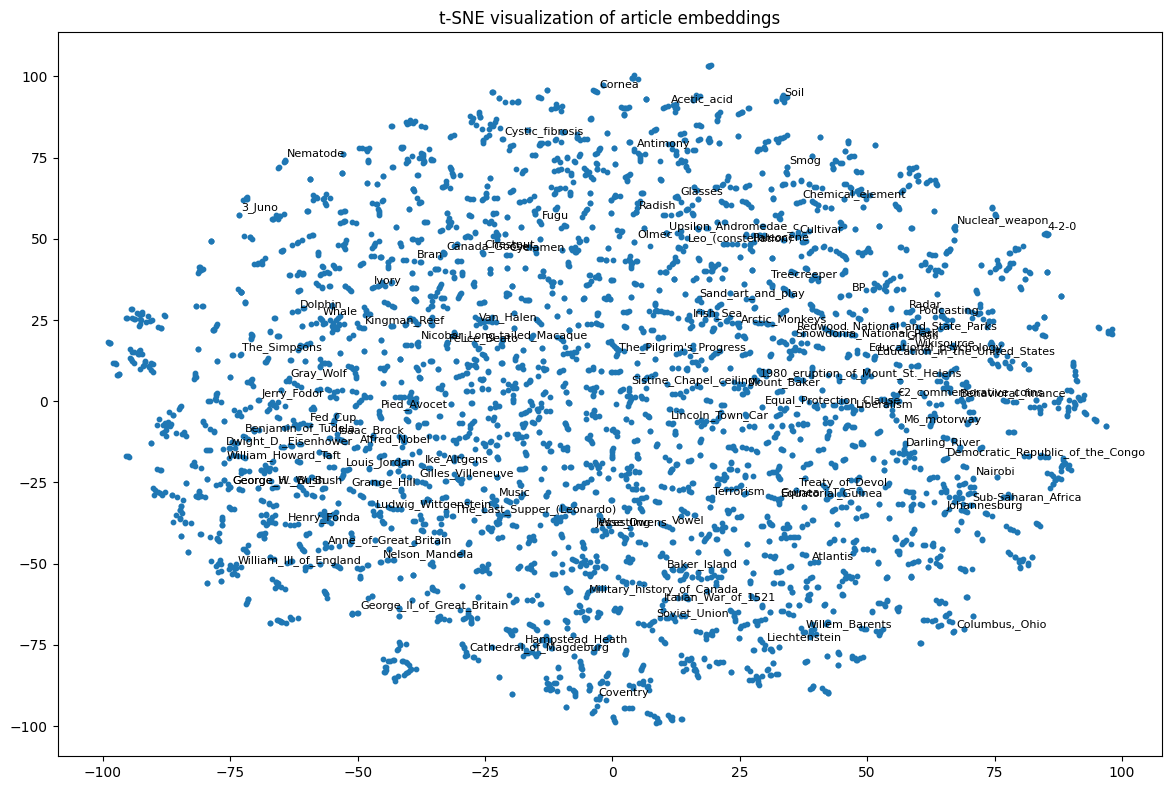

In [24]:
#semantic distribution of articles
visualizer.visualize_semantic_space(
    filename="semantic_space.png",
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt"
)

We can also visualize the association between average hops and average rating for the top start-destination paths. The result indicates that more difficult paths (lower rating) tend to have more hops on average.

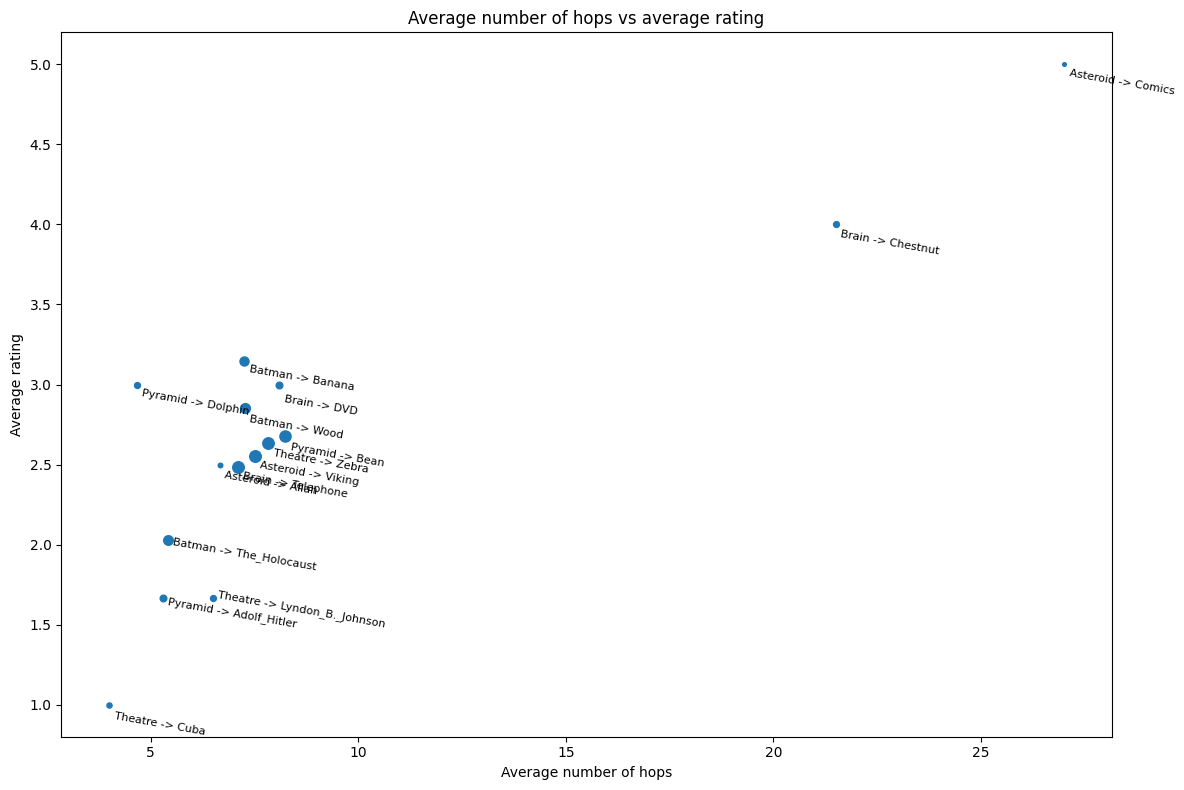

In [25]:
# average hops vs average rating within the above start-destination paths (only for finished paths), scatters are corrected by count [np.log() * 10]
visualizer.visualize_top_k_avg_hops(top_k_df, 'average_hops_vs_average_rating.png')

Below is the hop distribution for paths from Brain to Telephone, only considering finished paths:

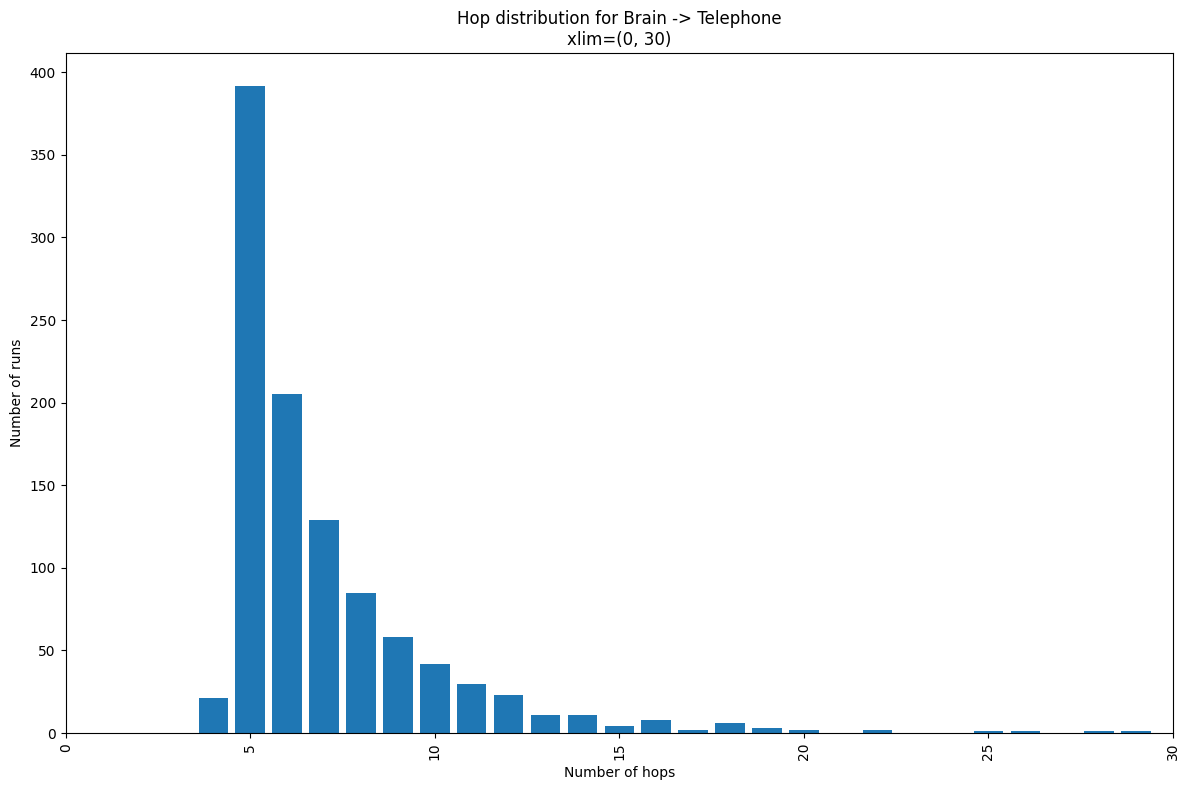

In [26]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

We can see that most paths from Brain to Telephone have around 5 hops.

<h2>Information Gain Analysis</h2>

We can analyze the information gain along the navigation paths from start to destination. The information gain is calculated based on the cosine similarity between current article and target article embeddings obtained from a sentence transformer model. Below is an example of analyzing the information gain for paths from "Brain" to "Telephone".

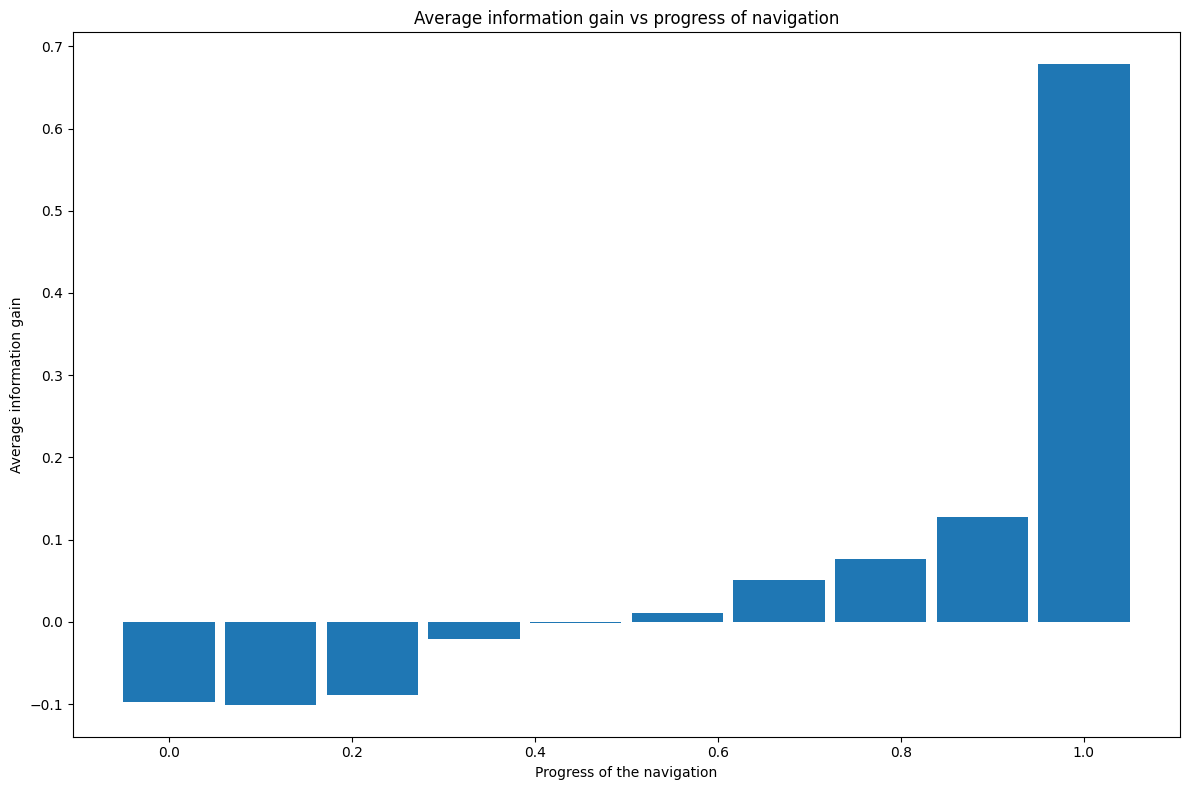

In [27]:
# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

Here we have an example test on path generation using a LLM agent. The agent uses the Tree of Thoughts (ToT) approach to generate navigation paths from start to destination.

<h1>Comparison of Human players vs LLMs</h1>


#### Load LLM genereated paths

In [1]:
%load_ext autoreload
%autoreload 2
    # initializing high level instances, with config
from preprocessor import Preprocessor
from config_local import config
import pandas as pd
from visualizer import Visualizer
import torch
from sklearn.cluster import KMeans

# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

In [2]:
# Load  genereated paths by the LLMs
#llm_df = pd.read_csv("results/llm_paths_oss_20b.csv")
llm_df = pd.read_csv("results/llm_paths_oss_120b.csv")

### Data Preprocessing

#### Clean LLM generated paths

In [3]:
# Clean LLMs paths (None, NaNs, loops, hallucationed articles)
blind_paths = preprocessor.clean_llm_paths(llm_df, "blind_paths")                        # One-shot 
link_aware_paths = preprocessor.clean_llm_paths(llm_df, "link_aware_paths")              # CoT
external_info_paths = preprocessor.clean_llm_paths(llm_df, "external_info_paths")        # CoT with knowledge graph information
tot_paths = preprocessor.clean_llm_paths(llm_df, "tot_paths")                            # ToT

# Print summary and sample
print("blind_paths:")
print(f"blind_paths: {len(blind_paths)} paths cleaned")
print(f"Sample: {blind_paths['path_list'].iloc[42]}")
print(f"Total NaNs after cleaning: {blind_paths.isna().sum().sum()}")
print("--------------------")

print("link_aware_paths:")
print(f"link_aware_paths: {len(link_aware_paths)} paths cleaned")
print(f"Sample: {link_aware_paths['path_list'].iloc[42]}")
print(f"Total NaNs after cleaning: {link_aware_paths.isna().sum().sum()}")
print("--------------------")

print("external_info_paths:")
print(f"external_info_paths: {len(external_info_paths)} paths cleaned")
print(f"Sample: {external_info_paths['path_list'].iloc[42]}")
print(f"Total NaNs after cleaning: {external_info_paths.isna().sum().sum()}")
print("--------------------")

print("tot_paths:")
print(f"tot_paths: {len(tot_paths)} paths cleaned")
print(f"Sample: {tot_paths['path_list'].iloc[42]}")
print(f"Total NaNs after cleaning: {tot_paths.isna().sum().sum()}")
print("--------------------")

blind_paths:
blind_paths: 233 paths cleaned
Sample: ['Asteroid', 'Space', 'NASA', 'Viking program', 'Viking']
Total NaNs after cleaning: 0
--------------------
link_aware_paths:
link_aware_paths: 189 paths cleaned
Sample: ['Archbishop_of_Canterbury', 'Roman_Catholic_Church', 'Asia', 'Vietnam']
Total NaNs after cleaning: 0
--------------------
external_info_paths:
external_info_paths: 197 paths cleaned
Sample: ['Batman', 'Crime', 'Religion', 'Bible']
Total NaNs after cleaning: 0
--------------------
tot_paths:
tot_paths: 199 paths cleaned
Sample: ['Batman', 'Crime', 'Religion', 'Bible']
Total NaNs after cleaning: 0
--------------------


### Categorical Shifts

In [4]:
# Get caterories
categories = preprocessor.parse_input_file(config.input_file_categories)

# Define method to extract the categories for the  article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

#### Map LLMs Player Article Navigation Paths to Categories

In [5]:
# Map all LLM paths to categories
# Blind paths: One-shot
blind_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in blind_paths['path_list']
]

# Link aware paths: CoT
link_aware_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in link_aware_paths['path_list']
]

# External info paths:  CoT with knowledge graph information
external_info_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in external_info_paths['path_list']
]

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in tot_paths['path_list']
]

# Inspect
#blind_article_cats
#link_aware_article_cats
#external_info_article_cats
#tot_article_cats

# Count unknows
unknown_counts_blind = sum(inner.count("Unknown") for inner in blind_article_cats)
#unknown_counts_link = sum(inner.count("Unknown") for inner in link_aware_article_cats)
#unknown_counts_ext = sum(inner.count("Unknown") for inner in external_info_article_cats)
#unknown_counts_tot = sum(inner.count("Unknown") for inner in tot_article_cats)
print(unknown_counts_blind)

455


In [6]:
blind_article_cats = [p for p in blind_article_cats if "Unknown" not in p]
len(blind_article_cats)

28

Only one-shot unknows (non-existing articles mappings) : excluding one-shot (blind_paths) due to hallucations...

#### Map Human Player Article Navigation Paths to Categories

In [7]:
# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

### Stepwise Mean Categorical Shifts Comparison

#### Compute the categorical shifts per navigatin path and step for LLMs

In [8]:
# Adaspeedia llm paths results (test)
#shifts_path_llms, shifts_step_llms = preprocessor.get_shifts_per_path(llm_article_cats_finished)

# Blind paths: One-shot
blind_paths_shift, blind_steps_shift = preprocessor.get_shifts_per_path(blind_article_cats)

# Link aware paths: CoT
link_aware_paths_shift, link_aware_steps_shift = preprocessor.get_shifts_per_path(link_aware_article_cats)

# External info paths:  CoT with knowledge graph information
external_info_paths_shift, external_info_steps_shift = preprocessor.get_shifts_per_path(external_info_article_cats)

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_paths_shift, tot_steps_shift = preprocessor.get_shifts_per_path(tot_article_cats)

#### Compute the categorical shifts per navigatin path and step for Humans

In [9]:
# Humans: Categorical shifts per navigatin path
shifts_path_humans, shifts_step_humans = preprocessor.get_shifts_per_path(article_cats_finished)

#### Compare the average categorial shifts along the entire navigation paths

In [10]:
# Compute average categorical shifts per navigation path for Humans
average_shift_humans = preprocessor.get_average_categorical_shifts_path(article_cats_finished)
print(f"Average categorical shift along entire navigation paths (Humans): {average_shift_humans:.3f}")

# Compute average categorical shifts per navigation path for LLMs:
# Blind paths: One-shot
average_shift_blind = preprocessor.get_average_categorical_shifts_path(blind_article_cats)
print(f"Average categorical shift along entire navigation paths (blind_paths): {average_shift_blind:.3f}")

# Link aware paths: CoT
average_shift_link_aware = preprocessor.get_average_categorical_shifts_path(link_aware_article_cats )
print(f"Average categorical shift along entire navigation paths (link_aware_paths): {average_shift_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_external_info = preprocessor.get_average_categorical_shifts_path(external_info_article_cats )
print(f"Average categorical shift along entire navigation paths (external_info_paths): {average_shift_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_tot = preprocessor.get_average_categorical_shifts_path(tot_article_cats )
print(f"Average categorical shift along entire navigation paths (tot_paths): {average_shift_tot:.3f}")

Average categorical shift along entire navigation paths (Humans): 4.577
Average categorical shift along entire navigation paths (blind_paths): 2.357
Average categorical shift along entire navigation paths (link_aware_paths): 3.074
Average categorical shift along entire navigation paths (external_info_paths): 3.183
Average categorical shift along entire navigation paths (tot_paths): 3.206


In [11]:
# Compute proportion of consecutive article pairs (i.e., per navigatio step)  involving a categorical shift for Humans
average_shift_steps_humans = preprocessor.get_average_categorical_shifts_step(article_cats_finished)
print(f"Proportion of consecutive article pairs involving a categorical shift (Humans): {average_shift_steps_humans:.3f}")


# Compute proportion of consecutive article pairs (i.e., per navigatio step) involving a categorical shift for LLMs
print("=====================================================================================")
print(f"Proportion of consecutive article pairs involving a categorical shift For LLMs:")

# Blind paths: One-shot
average_shift_step_blind = preprocessor.get_average_categorical_shifts_step(blind_article_cats)
print(f"One-shot {average_shift_step_blind:.3f}")

# Link aware paths: CoT
average_shift_step_link_aware = preprocessor.get_average_categorical_shifts_step(link_aware_article_cats)
print(f"CoT {average_shift_step_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_step_external_info = preprocessor.get_average_categorical_shifts_step(external_info_article_cats)
print(f"CoT (KB): {average_shift_step_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_step_tot = preprocessor.get_average_categorical_shifts_step(tot_article_cats)
print(f"ToT: {average_shift_step_tot:.3f}")

Proportion of consecutive article pairs involving a categorical shift (Humans): 0.795
Proportion of consecutive article pairs involving a categorical shift For LLMs:
One-shot 0.725
CoT 0.750
CoT (KB): 0.759
ToT: 0.773


#### Compare step-wise mean categorical shits along the entire navigation paths (normalized as progress [0,1])

In [12]:
# Compute stepwise shift vectors for each player type
shifts_step_humans       = preprocessor.compute_stepwise_shift_vectors(article_cats_finished)
#blind_steps_shift        = preprocessor.compute_stepwise_shift_vectors(blind_article_cats)
link_aware_steps_shift   = preprocessor.compute_stepwise_shift_vectors(link_aware_article_cats)
external_info_steps_shift= preprocessor.compute_stepwise_shift_vectors(external_info_article_cats)
tot_steps_shift          = preprocessor.compute_stepwise_shift_vectors(tot_article_cats)

cat_shift_dict = {
    "Humans": shifts_step_humans,
    #"One-shot": blind_steps_shift,
    "CoT": link_aware_steps_shift,
    "CoT(KB)": external_info_steps_shift,
    "ToT": tot_steps_shift
}


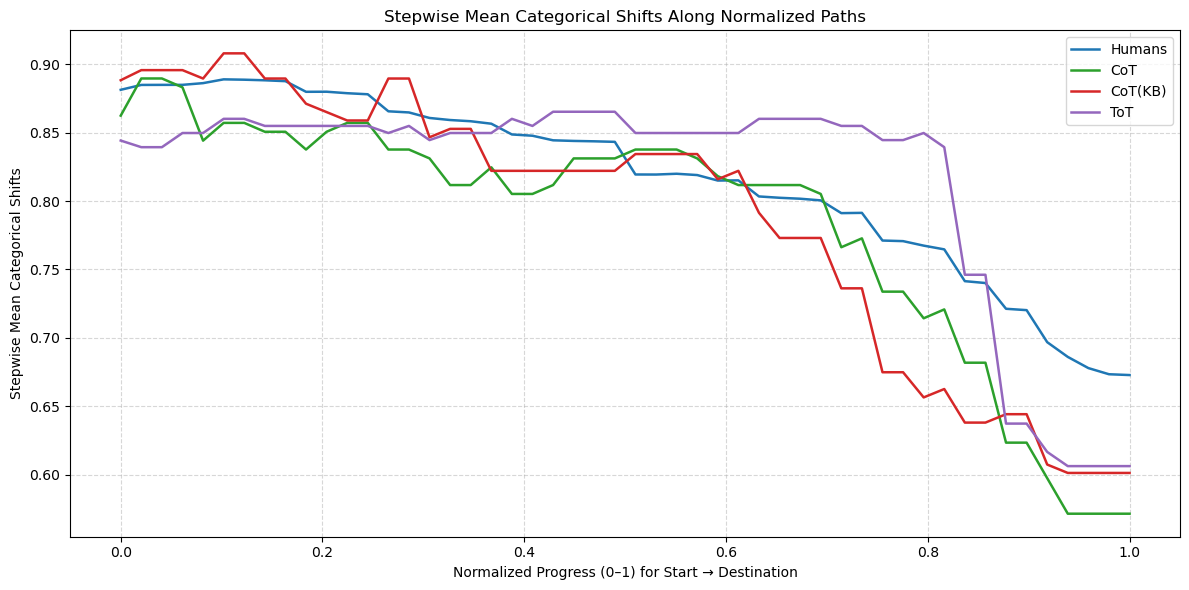

In [13]:
# Compute stepwise mean categorical shifts
mean_shifts_normal = preprocessor.compute_stepwise_mean_shifts(cat_shift_dict)

# Plot Step-wise mean categorical shifts (Paths normalized [0,1])
visualizer.visualize_categorical_shifts_mean_stepwise(mean_shifts_normal)

### Examining Categorical Shifts for a Specific Path
Humans vs. ToT: Because ToT is the best performing LLM 

In [14]:
# Start and destinations pairs for human players
hum_pairs = set((x[0], x[-1]) for x in article_cats_finished)

# Start and destinations pairs for ToT
tot_pairs = [(x[0], x[-1]) for x in tot_article_cats]

# Pair matches between them
hum_tot_matches = [p for p in tot_pairs if p in hum_pairs]

# Top 5 matching pairs
hum_tot_matches_top = (
    pd.Series(hum_tot_matches)
      .value_counts()
      .head(5)
)

# Print top matches
hum_tot_matches_top

(Cartoons, Food_and_agriculture)                    14
(Electricity_and_Electronics, Divinities)            6
(Religious_figures_and_leaders, Asian_Countries)     6
(Mathematics, Food_and_agriculture)                  6
(Cartoons, Birds)                                    6
Name: count, dtype: int64

In [15]:
# Count how many times the match occur for each: Because need the same sample size and by the match count, we know that one of them only contain 14 samples
# Count in humans
hum_match_count = sum(
    1 for path in article_cats_finished
    if (path[0], path[-1]) == hum_tot_matches_top.index[0]
)

# Count for ToT 
tot_match_count = sum(
    1 for path in tot_article_cats
    if (path[0], path[-1]) == hum_tot_matches_top.index[0]
)

# Print no. of support for each player 
print(f"Top pair {hum_tot_matches_top.index[0]} occurs {hum_match_count} times in human paths.")
print(f"Top pair {hum_tot_matches_top.index[0]} occurs {tot_match_count} times in LLM paths.")

Top pair ('Cartoons', 'Food_and_agriculture') occurs 121 times in human paths.
Top pair ('Cartoons', 'Food_and_agriculture') occurs 14 times in LLM paths.


The discrepancy in support effectively mean we have to take 14 random samples from human players to ensure a fair comparison. Furhtermore, we limit the max length of the human players to 11 as above these for ToT resulted in hallucinations

In [16]:
import random

# Filter human paths for the pair and constraint to a max length of 11
human_top_paths = [
    path for path in article_cats_finished
    if (path[0], path[-1]) == hum_tot_matches_top.index[0] and len(path) <= 11
]

# Select 14 random samples
human_sampled = random.sample(human_top_paths, 14)

# Print to ensure we have correct no. of samples
print(f"Human samples: {len(human_sampled)}")

Human samples: 14


#### Compare Humans against ToT using a Sankey Diagram

In [17]:
# Define start and end category for humans
cat_shift_hum_pairs = preprocessor.get_category_shifts_df_pairs(human_sampled, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1])

# Define start and end category for ToT
cat_shift_tot_pairs = preprocessor.get_category_shifts_df_pairs(tot_article_cats, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1])

#### Human Sankey Diagram

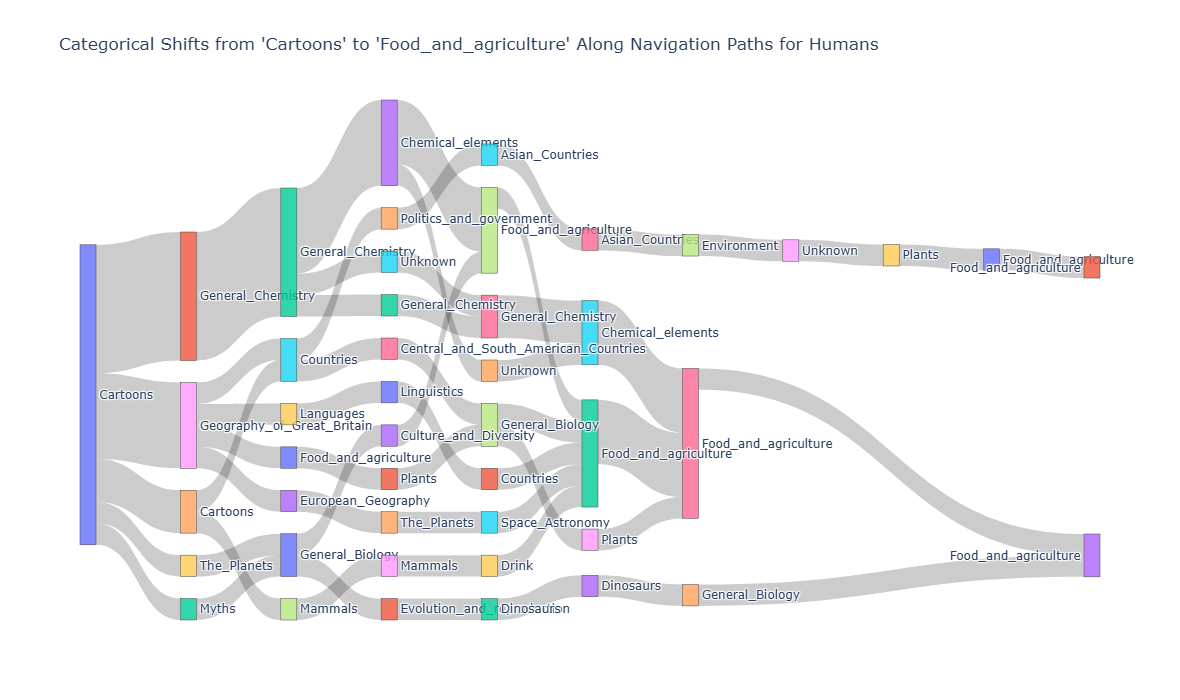

In [18]:
# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot_humans.png'
visualizer.visualize_sankey_plot(cat_shift_hum_pairs, filename, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1], "Humans")

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

#### ToT Sankey Diagram

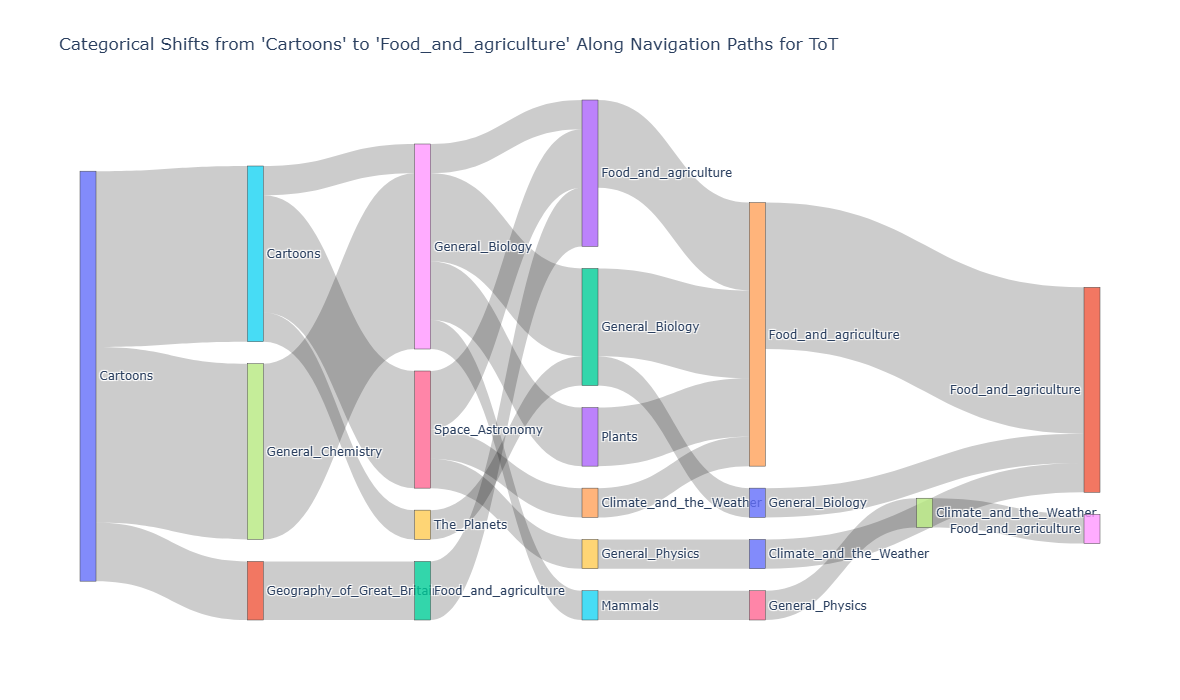

In [19]:
# Sankey diagram for ToT
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot_tot.png'
visualizer.visualize_sankey_plot(cat_shift_tot_pairs, filename, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1], "ToT")

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

### Semantical Similarity Comparison

#### Align Human Data (Finished paths for Wikispeedia) with the LLM paths generated
Ensure we only use the start/destination paths were an LLM example exist and do sampling to ensure same no. of path support for pairs

In [20]:
# Align Wikispeedia human players with the LLM generated pahts (i.e., there is a lot more human data than LLM data)
human_path_samples, _ = preprocessor.get_human_llm_match_samples(df, [blind_paths, link_aware_paths, external_info_paths, tot_paths], max_len=11, seed=42)

#### Load embeddings and metadata

In [21]:
embeddings = torch.load("results/article_emb/embeddings.pt", weights_only=True).numpy()
metadata = pd.read_csv("results/article_emb/metadata.csv")
article_to_idx = {row['article']: i for i, row in metadata.iterrows()}

Get the mean similarity, progress axis, and stepwise_similarity

In [22]:
sem_sim_dict = {
    "Humans": human_path_samples,
    #"One-shot": blind_paths["path_list"].tolist(),
    "CoT": link_aware_paths["path_list"].tolist(),
    "CoT(KB)": external_info_paths["path_list"].tolist(),
    "ToT": tot_paths["path_list"].tolist()
}

mean_similarity, progress_axis, stepwise_similarity = preprocessor.compute_stepwise_mean_similarity(
    sem_sim_dict,
    article_to_idx,
    embeddings
)

#### Plot temporal normalized progress plot showing the step-wise mean similarity

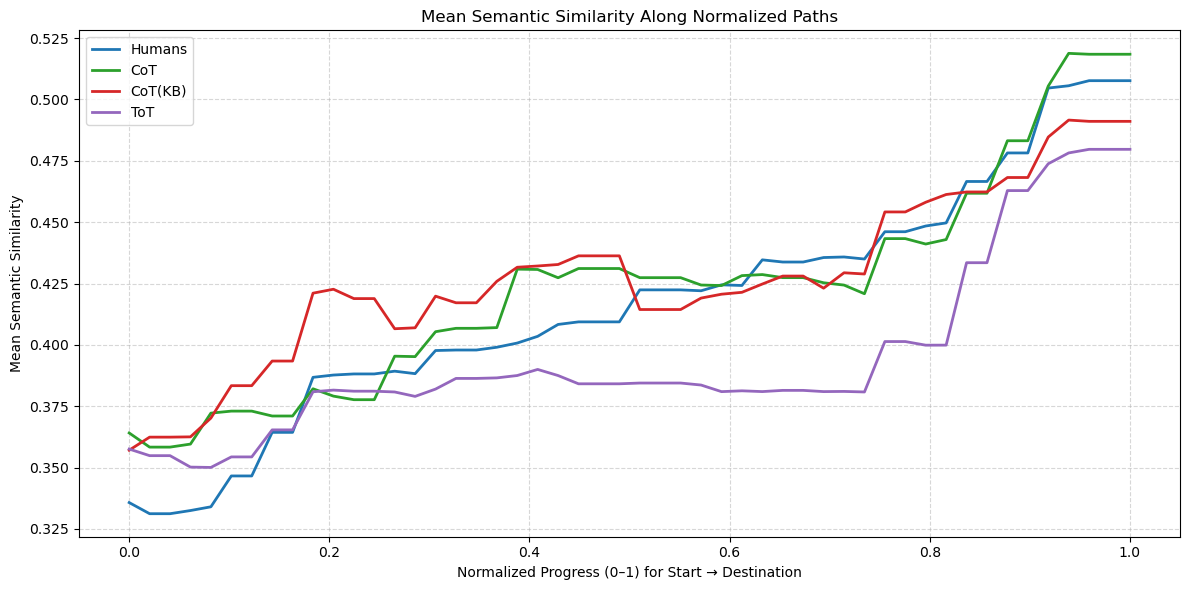

In [23]:
# Chart showing the step-weise mean similarity over normalized progress [0,1]
visualizer.visualize_stepwise_mean_similarity(mean_similarity, progress_axis)

#### Step-wise mean similarity distribution

In [24]:
stepwise_similarity_flat = preprocessor.compute_flat_stepwise_similarity(
    groups=sem_sim_dict,
    article_to_idx=article_to_idx,
    embeddings=embeddings
)

Violin plot for the step-wise similarity distribution

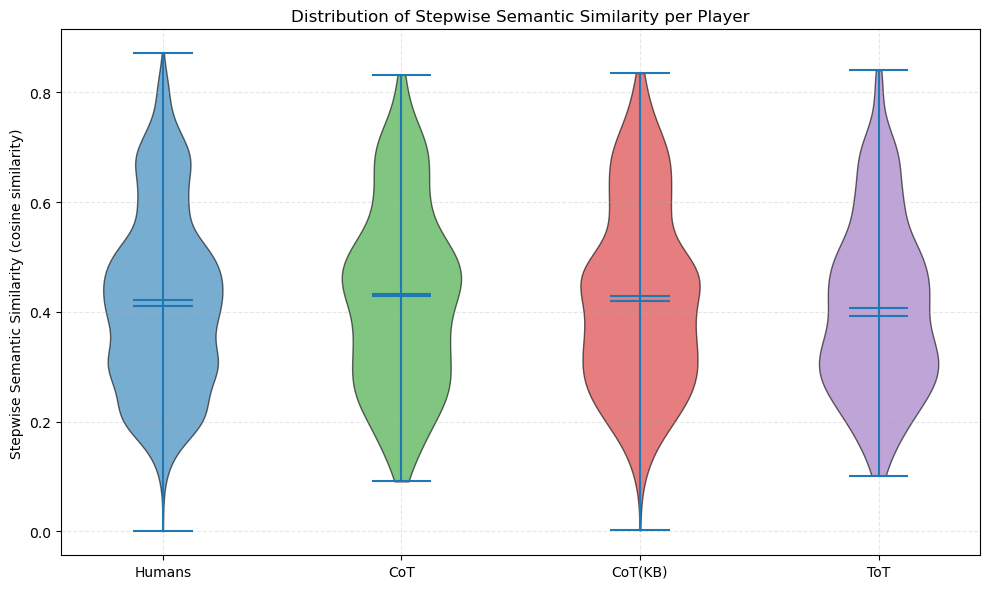

In [25]:
visualizer.plot_stepwise_similarity_violin(stepwise_similarity_flat)

### Plot the path length distributions 

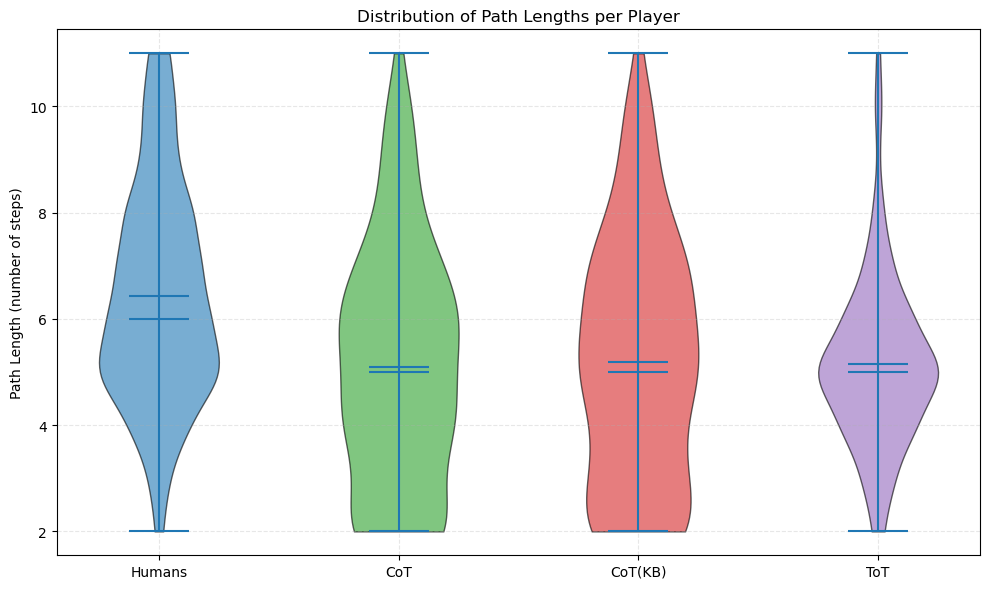

In [26]:
visualizer.plot_path_length_distribution(groups=sem_sim_dict)

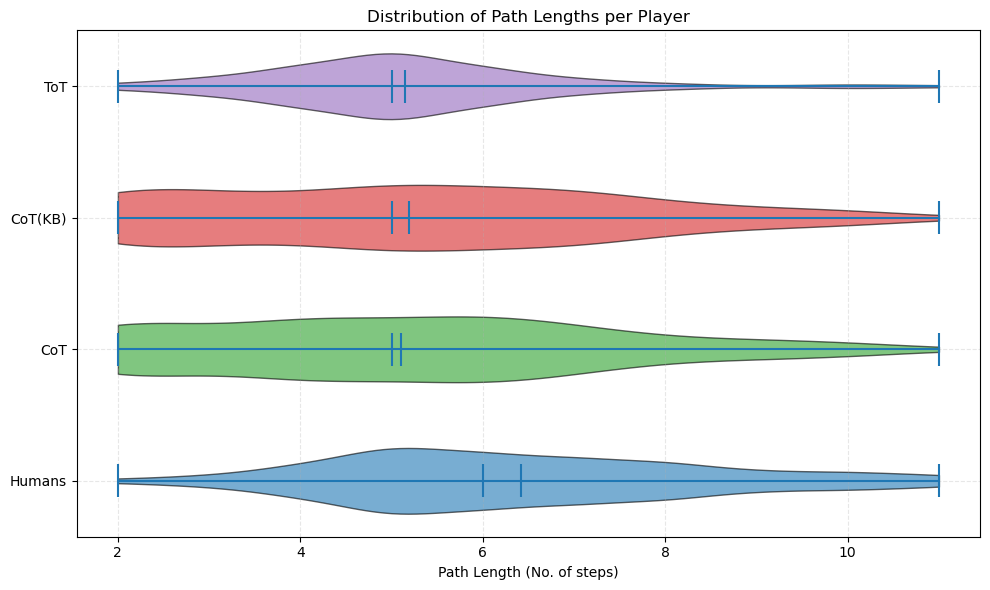

In [27]:
visualizer.plot_path_length_distribution_horizontal(groups=sem_sim_dict)

<h1>Generate Paths for LLMs</h1>

In [28]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)

# llm_tot_path = agent.navigate_tot(start, destination, with_memory=False)
# f'Path generated by LLM using ToT: {llm_tot_path}'

In [29]:
# llm_link_ware_path = agent.navigate_link_aware(start, destination)
# f'Path generated by LLM using link-aware approach: {llm_link_ware_path}'

In [30]:
# llm_blind_path = agent.navigate_blind(start, destination)
# f'Path generated by LLM using blind approach: {llm_blind_path}'

In [31]:
# llm_external_path = agent.navigate_with_external_info(start, destination)
# f'Path generated by LLM using external info approach: {llm_external_path}'

In [32]:
resolved_df.head()


,hashedIpAddress,timestamp,durationInSec,path,rating,source,target,type,start,end,num_hops,destination
0,6a3701d319fc3754,1297740409,166,"[14th_century, 15th_century, 16th_century, Pac...",NaN,finished,NaN,NaN,14th_century,African_slave_trade,9,African_slave_trade
1,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,finished,NaN,NaN,14th_century,African_slave_trade,5,African_slave_trade
2,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,finished,NaN,NaN,14th_century,African_slave_trade,8,African_slave_trade
3,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,finished,NaN,NaN,14th_century,Greece,4,Greece
4,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,finished,NaN,NaN,14th_century,John_F._Kennedy,7,John_F._Kennedy


In [33]:
df_for_experiment = preprocessor.get_pairs_for_experiment(resolved_df,num_pairs=20)             
#30 top played games
df_for_experiment

,start,destination,success_count,sample_count,success_rate,difficulty,replicate_idx,id
0,Brain,Telephone,1040,2044,0.508806,Medium,0,Brain_Telephone_0
1,Theatre,Zebra,905,1777,0.509285,Medium,0,Theatre_Zebra_0
2,Asteroid,Viking,1043,1770,0.589266,Medium,0,Asteroid_Viking_0
3,Batman,Wood,148,223,0.663677,Medium,0,Batman_Wood_0
4,Beer,Sun,99,142,0.697183,Medium,0,Beer_Sun_0
...,...,...,...,...,...,...,...,...
115,Napoleonic_Wars,Superman,5,14,0.357143,Hard,2,Napoleonic_Wars_Superman_2
116,Batman,Wikisource,4,13,0.307692,Hard,2,Batman_Wikisource_2
117,Christianity,Coconut_crab,4,13,0.307692,Hard,2,Christianity_Coconut_crab_2
118,David_Beckham,Frog,5,13,0.384615,Hard,2,David_Beckham_Frog_2


In [34]:
agent.generate_llm_paths(df_for_experiment)

Found 46 already completed pairs.
So far input price: 0.05$, output price: 0.35$


  0%|                                                                                                                                                               | 0/120 [00:00<?, ?it/s]

Skipping Brain_Telephone_0, since it has already been generated.
Skipping Theatre_Zebra_0, since it has already been generated.
Skipping Asteroid_Viking_0, since it has already been generated.
Skipping Batman_Wood_0, since it has already been generated.
Skipping Beer_Sun_0, since it has already been generated.
Skipping Batman_Banana_0, since it has already been generated.
Skipping Cat_Computer_0, since it has already been generated.
Skipping Cat_Microsoft_0, since it has already been generated.
Skipping Dog_Telephone_0, since it has already been generated.
Skipping Dog_Venus_0, since it has already been generated.
Skipping Aluminium_chloride_Parrot_0, since it has already been generated.
Skipping Batman_Bible_0, since it has already been generated.
Skipping England_God_0, since it has already been generated.
Skipping Art_Mango_0, since it has already been generated.
Skipping 14th_century_Rainbow_0, since it has already been generated.
Skipping Electricity_God_0, since it has already be

 39%|██████████████████████████████████████████████████████████▊                                                                                           | 47/120 [07:05<11:01,  9.06s/it]

Succeeded on attempt 1.
total input: 1013736 tokens so far
total output: 792399 tokens so far
So far input price: 0.05$, output price: 0.36$
elapsed time: 425.82 seconds
start: Cat, destination: Microsoft (replicate: 1)
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)
Attempt 2 starting.
Succeeded on attempt 2.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)
Attempt 2 starting.
Succeeded on attempt 2.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 

 40%|████████████████████████████████████████████████████████████                                                                                          | 48/120 [24:13<46:56, 39.12s/it]

Succeeded on attempt 1.
total input: 1059864 tokens so far
total output: 824532 tokens so far
So far input price: 0.05$, output price: 0.37$
elapsed time: 1027.94 seconds
start: Dog, destination: Telephone (replicate: 1)
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)


 40%|████████████████████████████████████████████████████████████                                                                                          | 48/120 [24:24<36:36, 30.51s/it]


KeyboardInterrupt: 